- ## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import pyccl as ccl
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d
from scipy.integrate import simpson
import os
from contextlib import redirect_stdout, redirect_stderr

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

- ## Configuration

In [2]:
class Config:
    
    COSMO_PARAMS = {
        "Omega_m": 0.315,
        "Omega_b": 0.05,
        "h": 0.67,
        "n_s": 0.96,
        "sigma8": 0.83,
        "M_nu": 0.0,
        "w0": -1.0,
        "wa": 0.0,
        "aexp": 1.0
    }
    
    TRANSFER_FUNCTION = "boltzmann_camb"
    
    C_LIGHT = 299792.458
    
    Z_MIN = 0.01
    Z_MAX = 3.0
    N_Z = 500
    Z0_GALAXY = 0.3
    
    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL = 50
    
    BIAS_B0 = 2.0
    BIAS_BETA = 0.5
    
    FR_VALUES = [4, 5, 6]
    
    BACCO_K_MIN = -2
    BACCO_K_MAX = None
    BACCO_N_K = 200
    EMANTIS_VERBOSE = False
    
    FIGURE_SIZE = (14, 10)
    
    K_MIN_SAFETY = 1.1
    K_MAX_SAFETY = 0.9
    K_CLIP_THRESHOLD = 0.05

- ## Cosmology Utilities

In [3]:
def comoving_distance(z, cosmo):
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        return ccl.comoving_radial_distance(cosmo, a) * cosmo['h']
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        return ccl.comoving_radial_distance(cosmo, a) * cosmo['h']


def hubble_parameter(z, cosmo, H0):
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        h_over_h0 = ccl.background.h_over_h0(cosmo, a)
        return H0 * h_over_h0
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        h_over_h0 = ccl.background.h_over_h0(cosmo, a)
        return H0 * h_over_h0


def growth_factor(z, cosmo):
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        return ccl.background.growth_factor(cosmo, a)
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        return ccl.background.growth_factor(cosmo, a)


def validate_growth_factor(z_grid, D_vals, D0):
    if abs(D0 - 1.0) > 1e-6:
        raise ValueError(
            f"CRITICAL ERROR: Growth factor not properly normalized!\n"
            f"  Expected D(0) = 1.0\n"
            f"  Got D(0) = {D0:.10f}\n"
            f"  Difference: {abs(D0 - 1.0):.2e}"
        )
    
    if np.any(D_vals <= 0):
        raise ValueError(
            f"CRITICAL ERROR: Non-positive growth factors detected!\n"
            f"  Min D(z) = {D_vals.min():.6f}"
        )
    
    growth_diff = np.diff(D_vals)
    n_decreasing = np.sum(growth_diff < -1e-12)
    
    if n_decreasing < 0.90 * len(growth_diff):
        raise ValueError(
            f"CRITICAL ERROR: Growth factor not decreasing as expected!\n"
            f"  Decreasing: {n_decreasing}/{len(growth_diff)}"
        )
    
    if D_vals[-1] < 0.1 or D_vals[-1] > D0:
        raise ValueError(f"CRITICAL ERROR: Growth factor values out of expected range!")
    
    return {"D0": D0, "D_max": D_vals[-1], "validated": True}


def galaxy_bias(D_array, D0, b0=2.0, beta=0.5):
    return b0 * (D0 / (D_array + 1e-30))**beta

- ## Galaxy and CMB Lensing Utilities

In [4]:
def galaxy_number_density_raw(z, z0=0.3):
    return np.exp(-z / z0)


def normalized_galaxy_distribution(z_array, z0=0.3):
    vals = galaxy_number_density_raw(z_array, z0=z0)
    norm = simpson(vals, z_array)
    
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError(f"Invalid dN/dz normalization: {norm}")
    
    return vals / norm


def cmb_lensing_kernel(z, cosmo, chi, Om_m, H0, c, z_star=1100.0):
    chi_star = comoving_distance(z_star, cosmo)
    prefactor = 1.5 * Om_m * (H0 / c)**2
    return prefactor * (1.0 + z) * chi * (chi_star - chi) / (chi_star + 1e-30)

- ## Power Spectrum Utilities

In [5]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            
            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())
            
            k = np.logspace(k_min, k_max, num=n_k)
            
            params_bacco = {
                "omega_cold": params["Omega_m"] - params["Omega_b"],
                "sigma8_cold": params["sigma8"],
                "omega_baryon": params["Omega_b"],
                "ns": params["n_s"],
                "hubble": params["h"],
                "neutrino_mass": params.get("M_nu", 0.0),
                "w0": params.get("w0", -1.0),
                "wa": params.get("wa", 0.0),
                "expfactor": params.get("aexp", 1.0)
            }
            
            k, Q_boost = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
            k, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)
    
    return k, pk_nl, Q_boost


def initialize_emantis_emulator(verbose=False):
    return NonLinearMGBoostEmulator(verbose=verbose)


def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    params_emantis = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0
    }
    
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)


def create_power_spectrum_interpolator(k, pk):
    return interp1d(
        np.log(k), 
        np.log(pk + 1e-50),
        kind='cubic', 
        bounds_error=False, 
        fill_value='extrapolate'
    )


def check_k_bounds(k_vals, k_min, k_max, ell, spectrum_name, threshold=0.05):
    k_safe = np.clip(k_vals, k_min, k_max)
    return k_safe

- ## Angular Power Spectrum Computation

In [6]:
def compute_Cl_galaxy_auto(ell_array, pk_interp_log, cosmo, z_grid, dNdz, 
                            chi_vals, H_vals, D_vals, D0, c,
                            b0=2.0, beta=0.5, k_min=None, k_max=None):
    b_vals = galaxy_bias(D_vals, D0, b0=b0, beta=beta)
    Wg = b_vals * dNdz
    
    Cl = np.zeros_like(ell_array, dtype=float)
    
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^gg")
        else:
            k_safe = k_vals
        
        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10
        
        P_kz = P0 * (D_vals / D0)**2
        
        integrand = (H_vals / c) * (Wg**2) * P_kz / (chi_vals**2)
        Cl[i] = simpson(integrand, z_grid)
    
    return Cl


def compute_Cl_galaxy_cmb_cross(ell_array, pk_interp_log, cosmo, z_grid, dNdz,
                                 chi_vals, H_vals, D_vals, D0, Wkappa_vals, c,
                                 b0=2.0, beta=0.5, k_min=None, k_max=None):
    b_vals = galaxy_bias(D_vals, D0, b0=b0, beta=beta)
    Wg = b_vals * dNdz
    
    Cl = np.zeros_like(ell_array, dtype=float)
    
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^κg")
        else:
            k_safe = k_vals
        
        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10
        
        P_kz = P0 * (D_vals / D0)**2
        
        integrand = (H_vals / c) * (Wkappa_vals * Wg) * P_kz / (chi_vals**2)
        Cl[i] = simpson(integrand, z_grid)
    
    return Cl

- ## Plotting Functions

In [14]:
def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None, 
                       fR_values=None, figsize=(14, 10)):
    fig = plt.figure(figsize=figsize)
    
    plt.subplot(2, 2, 1)
    plt.loglog(ell, Cl_gg_gr, 'b-', linewidth=2.5, 
               label=r'$C_\ell^{gg} \; [\mathrm{GR}]$')
    
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["gg"]:
                plt.loglog(ell, fr_results["gg"][logfR0_val], '--', linewidth=2,
                          label=rf'$C_\ell^{{gg}} \; [f(R): f_{{R0}}=-10^{{-{logfR0_val}}}]$')
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}$', fontsize=12)
    plt.title(r'Galaxy Auto Spectrum: $C_\ell^{gg}$', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    
    plt.subplot(2, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), 'b-', linewidth=2.5,
               label=r'$C_\ell^{\kappa g} \; [\mathrm{GR}]$')
    
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["kg"]:
                plt.loglog(ell, np.abs(fr_results["kg"][logfR0_val]), '--', linewidth=2,
                          label=rf'$C_\ell^{{\kappa g}} \; [f(R): f_{{R0}}=-10^{{-{logfR0_val}}}]$')
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
    plt.title(r'CMB Lensing × Galaxy Cross: $C_\ell^{\kappa g}$', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    
    plt.subplot(2, 2, 3)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["gg"]:
                ratio = fr_results["gg"][logfR0_val] / Cl_gg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                            label=rf'$f_{{R0}}=-10^{{-{logfR0_val}}}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}(f(R)) / C_\ell^{gg}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy Auto Spectrum Ratio', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])
    
    plt.subplot(2, 2, 4)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["kg"]:
                ratio = fr_results["kg"][logfR0_val] / Cl_kg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                            label=rf'$f_{{R0}}=-10^{{-{logfR0_val}}}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{\kappa g}(f(R)) / C_\ell^{\kappa g}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy-CMB Cross Spectrum Ratio', fontsize=14)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])
    
    plt.tight_layout()
    return fig

- ## Initialize Cosmology

In [15]:
H0 = Config.COSMO_PARAMS["h"] * 100.0
Om_m = Config.COSMO_PARAMS["Omega_m"]

cosmo_ccl = ccl.Cosmology(
    Omega_c=Config.COSMO_PARAMS["Omega_m"] - Config.COSMO_PARAMS["Omega_b"],
    Omega_b=Config.COSMO_PARAMS["Omega_b"],
    h=Config.COSMO_PARAMS["h"],
    sigma8=Config.COSMO_PARAMS["sigma8"],
    n_s=Config.COSMO_PARAMS["n_s"],
    w0=Config.COSMO_PARAMS["w0"],
    wa=Config.COSMO_PARAMS["wa"],
    m_nu=Config.COSMO_PARAMS["M_nu"],
    transfer_function=Config.TRANSFER_FUNCTION
)

- ## Compute Matter Power Spectra

In [16]:
k, pk_nl_gr, Q_boost = initialize_bacco_emulator(Config.COSMO_PARAMS)
pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)

emantis_emu = initialize_emantis_emulator()

- ## Pre-compute Redshift-Dependent Quantities

In [17]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

dNdz = normalized_galaxy_distribution(z_grid, z0=Config.Z0_GALAXY)

chi_vals = comoving_distance(z_grid, cosmo_ccl)
H_vals = hubble_parameter(z_grid, cosmo_ccl, H0)

D_vals = growth_factor(z_grid, cosmo_ccl)
D0 = growth_factor(0.0, cosmo_ccl)

Wkappa_vals = cmb_lensing_kernel(
    z_grid, cosmo_ccl, chi_vals, Om_m, H0, Config.C_LIGHT
)

validation_results = validate_growth_factor(z_grid, D_vals, D0)

- ## Compute Angular Power Spectra for GR

In [18]:
ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

Cl_gg_gr = compute_Cl_galaxy_auto(
    ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Config.C_LIGHT,
    b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
    k_min=k_min_safe, k_max=k_max_safe
)

Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
    ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.C_LIGHT,
    b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
    k_min=k_min_safe, k_max=k_max_safe
)

- ## Compute Angular Power Spectra for f(R) Gravity

In [19]:
fr_results = {"gg": {}, "kg": {}}

for logfR0_val in Config.FR_VALUES:
    pk_boost = compute_fR_boost(
        emantis_emu, Config.COSMO_PARAMS, logfR0_val, k, aexp=Config.COSMO_PARAMS["aexp"]
    )
    pk_fR = pk_nl_gr * pk_boost
    pk_interp_fr = create_power_spectrum_interpolator(k, pk_fR)
    
    Cl_gg_fr = compute_Cl_galaxy_auto(
        ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Config.C_LIGHT,
        b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
        k_min=k_min_safe, k_max=k_max_safe
    )
    
    Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
        ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.C_LIGHT,
        b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
        k_min=k_min_safe, k_max=k_max_safe
    )
    
    fr_results["gg"][logfR0_val] = Cl_gg_fr
    fr_results["kg"][logfR0_val] = Cl_kg_fr

- ## Plot Results

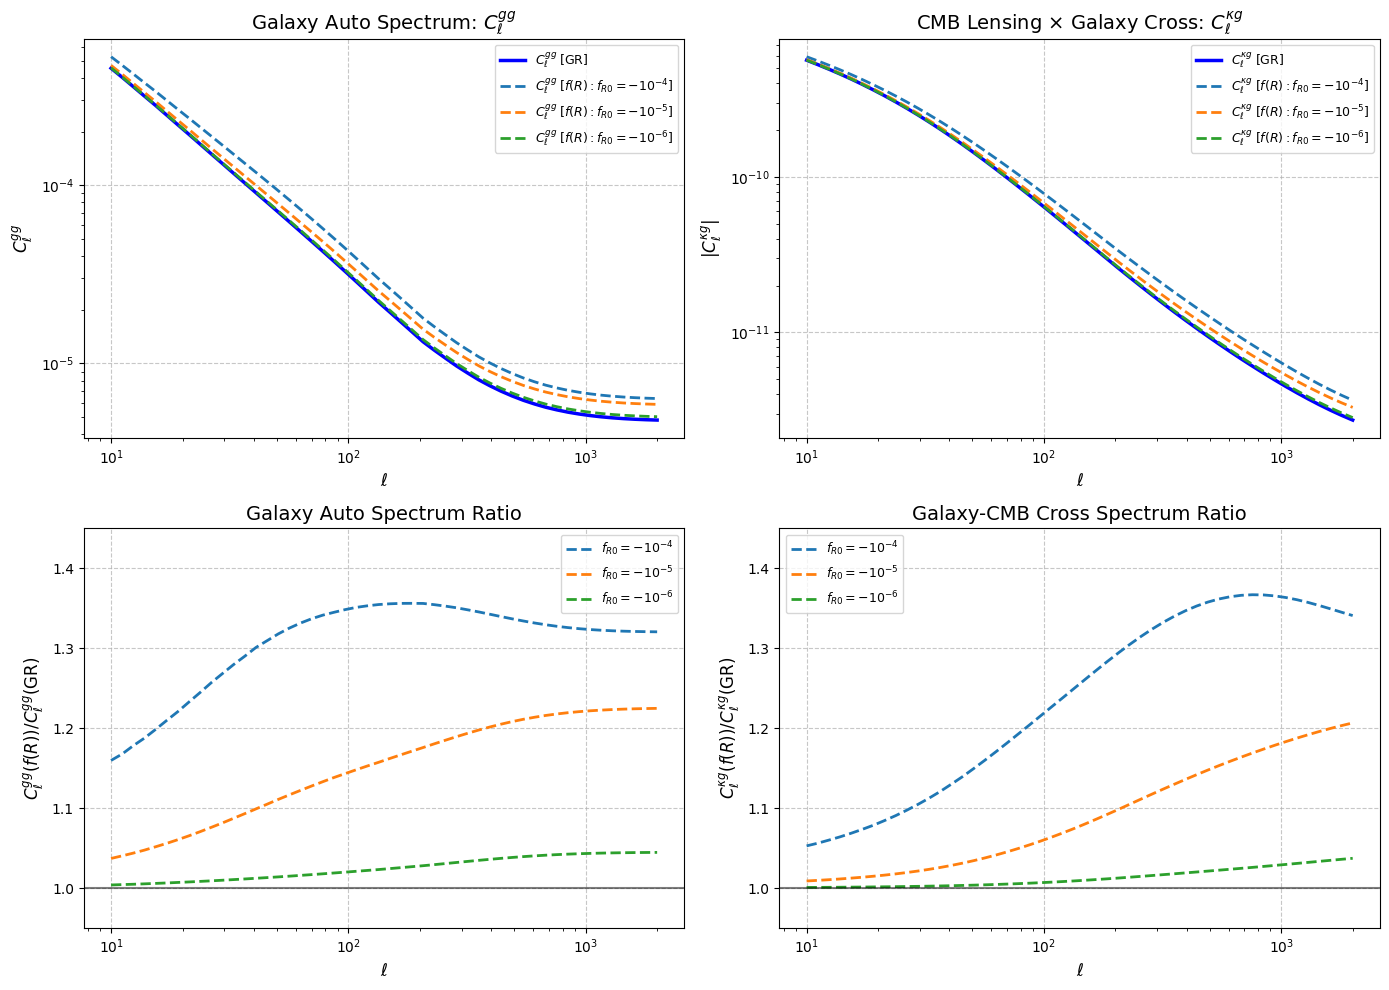

Analysis complete!


In [20]:
fig = plot_power_spectra(
    ell, Cl_gg_gr, Cl_kg_gr, 
    fr_results=fr_results, 
    fR_values=Config.FR_VALUES
)
plt.show()

print("Analysis complete!")